# Logistic Regression Training

## Step 1: Data Collection

### Import Necessary Libraries

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score,roc_curve
from sklearn.model_selection import train_test_split

###Import Dataset

In [ ]:
claimants_data = pd.read_csv("claimants.csv")
claimants_data


,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


## Step 3: Data Understanding

### Perform initial investigation


In [ ]:
claimants_data.shape

(1340, 7)

In [ ]:
claimants_data.isna().sum()

,0
CASENUM,0
ATTORNEY,0
CLMSEX,12
CLMINSUR,41
SEATBELT,48
CLMAGE,189
LOSS,0


### Since most of the input feature contains the nan that will affect the model prediction so the better decision is to reach out to client and convey the nan entries in the dataset, and if the client is ok to clean the data then it is better to drop the nan observation for good prediction

In [ ]:
claimants_data.dropna(inplace=True)

In [ ]:
claimants_data.shape

(1096, 7)

In [ ]:
claimants_data.dtypes

,0
CASENUM,int64
ATTORNEY,int64
CLMSEX,float64
CLMINSUR,float64
SEATBELT,float64
CLMAGE,float64
LOSS,float64


## Step 4: Data Understanding

In [ ]:
claimants_data

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...
1334,1.0,1.0,0.0,16.0,0.060
1336,1.0,1.0,0.0,46.0,3.705
1337,1.0,1.0,0.0,39.0,0.099
1338,1.0,0.0,0.0,8.0,3.177


In [ ]:
claimants_data.isna().sum()

,0
CASENUM,0
ATTORNEY,0
CLMSEX,0
CLMINSUR,0
SEATBELT,0
CLMAGE,0
LOSS,0


###The casenum and attorney column is not considered as input feature, the best decision is to drop it

In [ ]:
X= claimants_data.drop(labels=['CASENUM','ATTORNEY'],axis=1)
y = claimants_data['ATTORNEY']


## Step 5: Model Building

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=True,
    random_state=40
)

In [ ]:
logistic_model = LogisticRegression()


## Step 6: Model Training

In [ ]:
logistic_model.fit(X_train,y_train)

LogisticRegression()

## Step 7: Model Testing

### Training Prediction

In [ ]:
y_pred_train = logistic_model.predict(X_train)

###Test prediction

In [ ]:
y_pred_test = logistic_model.predict(X_test)

## Step 8: Model Evaluation

### Train data Evaluation

In [ ]:
print(confusion_matrix(y_train,
                 y_pred_train))

[[303 159]
 [ 94 320]]


In [ ]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.76      0.66      0.71       462
           1       0.67      0.77      0.72       414

    accuracy                           0.71       876
   macro avg       0.72      0.71      0.71       876
weighted avg       0.72      0.71      0.71       876



### Roc Curve for training data

AUC Score: 0.7663514022209674


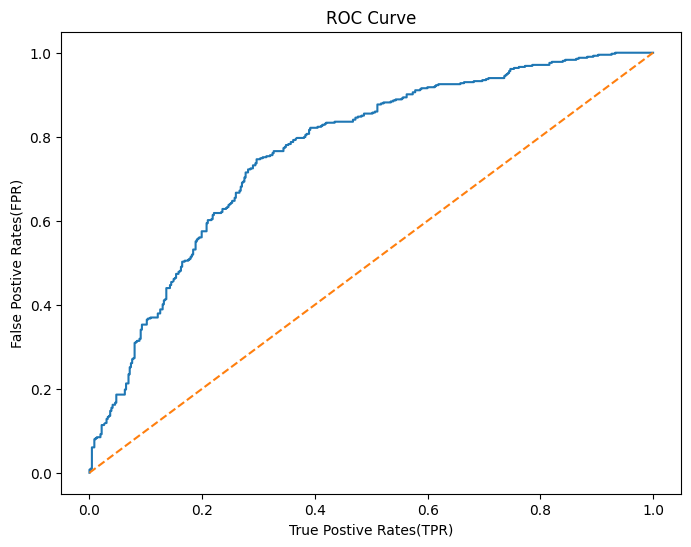

In [ ]:
y_prob = logistic_model.predict_proba(X_train)[:,1]
fpr,tpr,threshold = roc_curve(y_train,
                              y_prob)
auc_score = roc_auc_score(y_train,y_prob)
print("AUC Score:",auc_score)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],linestyle='--',label="random classifier")

plt.xlabel("True Postive Rates(TPR)")
plt.ylabel("False Postive Rates(FPR)")
plt.title("ROC Curve")
plt.show()

In [ ]:
accuracy_score(y_train,y_pred_train)

0.7111872146118722

### Test Data Evaluation

####Confusion matrix for test data

In [ ]:
print(confusion_matrix(y_test,y_pred_test))

[[78 38]
 [32 72]]


####Classification report for test data


In [ ]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.71      0.67      0.69       116
           1       0.65      0.69      0.67       104

    accuracy                           0.68       220
   macro avg       0.68      0.68      0.68       220
weighted avg       0.68      0.68      0.68       220



### Roc Curve for Test Data

AUC Score: 0.7372347480106101


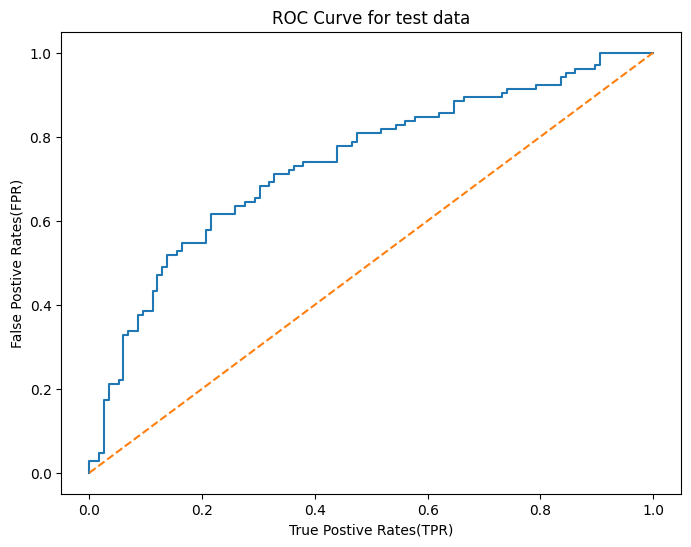

In [ ]:
y_prob = logistic_model.predict_proba(X_test)[:,1]
fpr,tpr,threshold = roc_curve(
    y_test,y_prob
)
auc_score = roc_auc_score(
    y_test,
    y_prob
)
print("AUC Score:",auc_score)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("True Postive Rates(TPR)")
plt.ylabel("False Postive Rates(FPR)")
plt.title("ROC Curve for test data")
plt.show()

In [ ]:
accuracy_score(y_test,y_pred_test)

0.6818181818181818

## Step 9: Model Deployment

In [ ]:
from pickle import dump
dump(logistic_model,open("claimants.pkl",'wb'))


### For loading the file into our application

In [ ]:
from pickle import load
logistic_intel_pkl =load(open("claimants.pkl",'rb'))
logistic_intel_pkl.predict(X)


array([0, 1, 1, ..., 1, 0, 1])